# Genetic Algorithm
Genetic representation: <br>
List of clients in order of being calculated.

Mutation: <br>
Swap mutation to change the path randomly. Each mutation will use one parent to make sure no duplicate clients get added.

Tournament selection: <br>
Used to get a fair spread of good and bad states.

Elitism survivor selection: <br>
To make sure we do not go back in progress.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import osmnx as ox
import numpy as np
from shapely import wkt

In [2]:
# Initialize all necessary parts of the genetic algorithm
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

POPULATION_SIZE = 100
EPOCHS = 500

MUTATION_RATE = 1.00
MUTATION_STRIDE = 2

TOURNAMENT_SIZE = 5
ELITE_SIZE = max(1, int(0.10 * POPULATION_SIZE))

MAX_EMPLOYEE_WORK_TIME_MIN = 8 * 60

print("GA initialized:")
print(f"  seed={RANDOM_SEED}, population={POPULATION_SIZE}, epochs={EPOCHS}")
print(f"  mutation_rate={MUTATION_RATE}, mutation_stride={MUTATION_STRIDE}")
print(f"  tournament={TOURNAMENT_SIZE}, elite_size={ELITE_SIZE}")

GA initialized:
  seed=42, population=100, epochs=500
  mutation_rate=1.0, mutation_stride=2
  tournament=5, elite_size=10


In [3]:
# ============= Initial Population =============
NUM_CLIENTS = 100
client_indices = list(range(NUM_CLIENTS))
initial_population = [np.random.permutation(client_indices).tolist() for _ in range(POPULATION_SIZE)]

print(f"Initialized population with {len(initial_population)} individuals.")
print(f"Each individual contains {len(initial_population[0])} client indices.")
print("First individual:")
print(initial_population[0])

Initialized population with 100 individuals.
Each individual contains 100 client indices.
First individual:
[83, 53, 70, 45, 44, 39, 22, 80, 10, 0, 18, 30, 73, 33, 90, 4, 76, 77, 12, 31, 55, 88, 26, 42, 69, 15, 40, 96, 9, 72, 11, 47, 85, 28, 93, 5, 66, 65, 35, 16, 49, 34, 7, 95, 27, 19, 81, 25, 62, 13, 24, 3, 17, 38, 8, 78, 6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68, 61, 97, 79, 41, 58, 48, 98, 57, 75, 32, 94, 59, 63, 84, 37, 29, 1, 52, 21, 2, 23, 87, 91, 74, 86, 82, 20, 60, 71, 14, 92, 51]


In [4]:
# ============= Mutation Function =============
def swap_mutation(parent):
    """
    Swap mutation: takes a single parent (list of client indices),
    creates a mutant by swapping MUTATION_STRIDE random position pairs.
    
    Args:
        parent: list of client indices representing a route order
        
    Returns:
        mutant: mutated copy of parent with swapped positions
    """
    mutant = parent.copy()
    
    # Perform MUTATION_STRIDE swaps
    for _ in range(MUTATION_STRIDE):
        # Select two random distinct indices
        i, j = np.random.choice(len(mutant), size=2, replace=False)
        # Swap them
        mutant[i], mutant[j] = mutant[j], mutant[i]
    
    return mutant

In [5]:
# ============= Tournament Selection =============
def tournament_selection(population, fitness_scores):
    """
    Tournament selection: randomly sample TOURNAMENT_SIZE individuals
    and return the best one (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        winner: selected individual from the tournament
        winner_fitness: fitness score of the selected individual
    """
    # Sample unique indices for the tournament
    tournament_size = min(TOURNAMENT_SIZE, len(population))
    candidate_indices = np.random.choice(len(population), size=tournament_size, replace=False)
    
    # Find index of the best candidate in the sampled set (lower fitness is better)
    best_local_idx = np.argmin([fitness_scores[i] for i in candidate_indices])
    winner_index = candidate_indices[best_local_idx]
    
    winner = population[winner_index]
    winner_fitness = fitness_scores[winner_index]
    
    return winner, winner_fitness

In [6]:
# ============= Elitism Selection =============
def elitism_selection(population, fitness_scores):
    """
    Elitism selection: preserve the top ELITE_SIZE individuals from the population
    based on their fitness scores (lower fitness is better for minimization).
    
    Args:
        population: list of individuals (each individual is a list of client indices)
        fitness_scores: list of fitness values corresponding to each individual
        
    Returns:
        elite_individuals: list of the ELITE_SIZE best individuals
        elite_fitness: list of fitness scores for the elite individuals
    """
    # Get indices sorted by fitness (ascending - lower is better)
    sorted_indices = np.argsort(fitness_scores)[:ELITE_SIZE]
    
    # Extract elite individuals and their fitness scores
    elite_individuals = [population[i] for i in sorted_indices]
    elite_fitness = [fitness_scores[i] for i in sorted_indices]
    
    return elite_individuals, elite_fitness

In [17]:
from shapely import wkt
from shapely.ops import transform
import geopandas as gpd
import numpy as np
import pandas as pd

clients_with_coords = pd.read_csv("../output/clients.csv")
heerlen_edge_table = pd.read_csv("../output/heerlen_edge_table.csv")


def parse_client_coordinates(value):
    try:
        first_part, second_part = str(value).strip().split()
        latitude = float(first_part)
        longitude = float(second_part)
        return latitude, longitude
    except Exception:
        return None


def parse_edge_geometry(value):
    try:
        return wkt.loads(str(value))
    except Exception:
        return None


def swap_xy(geometry):
    return transform(lambda x, y, z=None: (y, x), geometry)


def geometry_looks_reversed(geometry):
    if geometry is None or geometry.is_empty:
        return False
    if hasattr(geometry, "geoms"):
        coords = [coord for part in geometry.geoms for coord in part.coords]
    elif hasattr(geometry, "coords"):
        coords = list(geometry.coords)
    else:
        return False

    if not coords:
        return False

    x_values = [coord[0] for coord in coords]
    y_values = [coord[1] for coord in coords]
    return float(np.median(x_values)) > float(np.median(y_values))


# Build client points from the existing "coordinates" column, which is formatted as "latitude longitude".
clients_df = clients_with_coords.copy()
clients_df[["latitude", "longitude"]] = clients_df["coordinates"].apply(
    lambda value: pd.Series(parse_client_coordinates(value))
)
clients_df = clients_df.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
clients_gdf = gpd.GeoDataFrame(
    clients_df,
    geometry=gpd.points_from_xy(clients_df["longitude"], clients_df["latitude"]),
    crs="EPSG:4326",
)

# Normalize edge geometries if they were stored as "latitude longitude" instead of "longitude latitude".
edges_df = heerlen_edge_table.copy()
edges_df["geometry"] = edges_df["geometry"].apply(parse_edge_geometry)
edges_df = edges_df.dropna(subset=["geometry"]).reset_index(drop=True)
edges_df["edge_id"] = edges_df.index
edges_df["geometry"] = edges_df["geometry"].apply(
    lambda geometry: swap_xy(geometry) if geometry_looks_reversed(geometry) else geometry
)
edges_gdf = gpd.GeoDataFrame(edges_df, geometry="geometry", crs="EPSG:4326")

# Project to a metric CRS before measuring distances.
projected_crs = clients_gdf.estimate_utm_crs()
if projected_crs is None:
    projected_crs = "EPSG:3857"

clients_projected = clients_gdf.to_crs(projected_crs)
edges_projected = edges_gdf.to_crs(projected_crs)

# Find the nearest edge segment for each client.
nearest_clients = gpd.sjoin_nearest(
    clients_projected,
    edges_projected[["edge_id", "u", "v", "key", "name", "highway", "length", "travel_time", "travel_time_min", "geometry"]],
    how="left",
    distance_col="distance_m",
)

client_nearest_segments = nearest_clients[[
    "name_left",
    "address",
    "coordinates",
    "edge_id",
    "u",
    "v",
    "key",
    "name_right",
    "highway",
    "distance_m",
]].rename(
    columns={
        "name_left": "client_name",
        "name_right": "edge_name",
    }
)


client_nearest_segments.to_csv("../output/client_nearest_segments.csv", index=False)
client_nearest_segments.head(3)

,client_name,address,coordinates,edge_id,u,v,key,edge_name,highway,distance_m
0,Client 1,"Putgraaf 478, 6411KN Heerlen",50.8870305 5.9850058,2164,42033003,42032089,0,Groene Boord,tertiary,30.806634
1,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,5109,42071791,42071604,0,Asterstraat | Tulpstraat,residential,30.541292
1,Client 2,"Tulpstraat 63-GB04, Heerlen",50.9235901 5.9630637,5093,42071604,42071791,0,Asterstraat | Tulpstraat,residential,30.541292


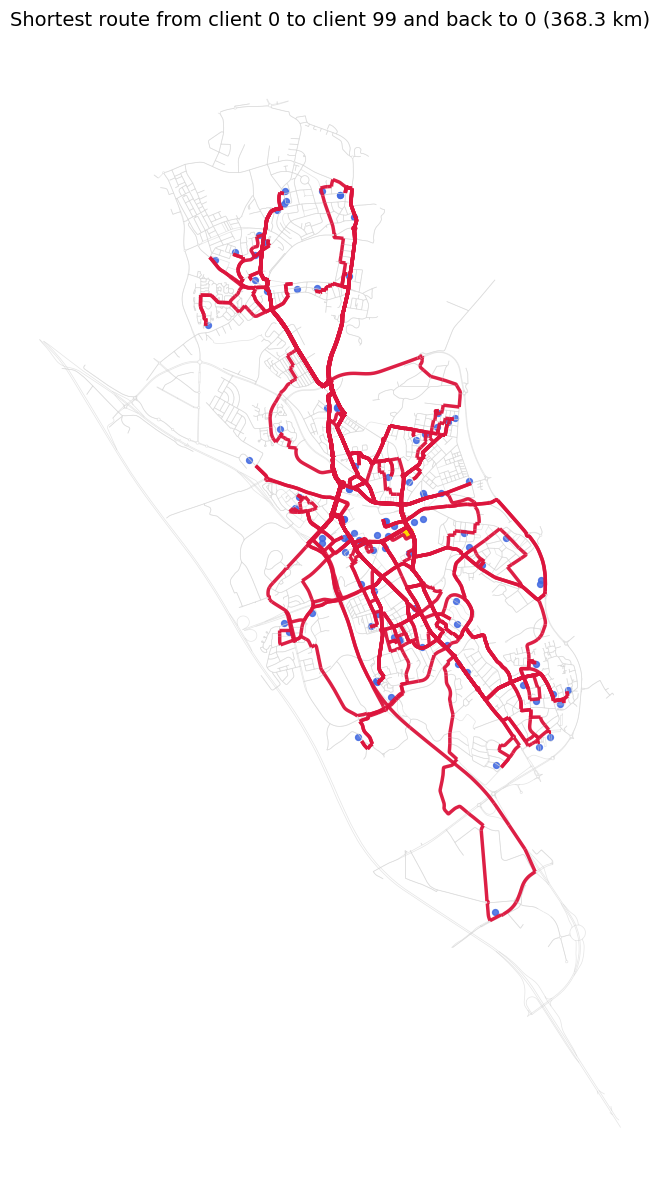

In [ ]:
# Go from client 1 through each other client back to 1
import networkx as nx
from itertools import pairwise
from shapely.geometry import LineString

# Build a road graph from the edge table that already has corrected geometry direction.
road_graph = nx.MultiDiGraph()
road_graph.graph["crs"] = "EPSG:4326"

for _, edge_row in edges_gdf.iterrows():
    geometry = edge_row["geometry"]
    if geometry is None or geometry.is_empty:
        continue

    line_parts = list(geometry.geoms) if geometry.geom_type == "MultiLineString" else [geometry]
    edge_attributes = edge_row.drop(labels=["geometry", "key"]).to_dict()

    for line in line_parts:
        coordinates = list(line.coords)
        if len(coordinates) < 2:
            continue

        start_x, start_y = coordinates[0]
        end_x, end_y = coordinates[-1]
        road_graph.add_node(edge_row["u"], x=start_x, y=start_y)
        road_graph.add_node(edge_row["v"], x=end_x, y=end_y)
        road_graph.add_edge(edge_row["u"], edge_row["v"], key=edge_row["key"], geometry=line, **edge_attributes)

# Route through client 0 -> 1 -> ... -> 99 -> 0.
num_route_clients = min(100, len(clients_gdf))
route_client_indices = list(range(num_route_clients)) + [0]
route_client_points = clients_gdf.loc[route_client_indices, "geometry"]
route_client_nodes = ox.nearest_nodes(
    road_graph,
    route_client_points.x.to_list(),
    route_client_points.y.to_list(),
)

route_geometries = []
route_total_length_m = 0.0

for start_node, end_node in pairwise(route_client_nodes):
    path_nodes = nx.shortest_path(road_graph, start_node, end_node, weight="length")
    route_total_length_m += nx.path_weight(road_graph, path_nodes, weight="length")

    for node_u, node_v in pairwise(path_nodes):
        edge_bundle = road_graph.get_edge_data(node_u, node_v)
        if not edge_bundle:
            route_geometries.append(
                LineString(
                    [
                        (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                        (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                    ]
                )
            )
            continue

        best_key = min(
            edge_bundle,
            key=lambda candidate_key: edge_bundle[candidate_key].get("length", float("inf")),
        )
        selected_edge = edge_bundle[best_key]
        geometry = selected_edge.get("geometry")
        if geometry is None:
            geometry = LineString(
                [
                    (road_graph.nodes[node_u]["x"], road_graph.nodes[node_u]["y"]),
                    (road_graph.nodes[node_v]["x"], road_graph.nodes[node_v]["y"]),
                ]
            )
        route_geometries.append(geometry)

route_gdf = gpd.GeoDataFrame(geometry=route_geometries, crs="EPSG:4326").to_crs(epsg=3857)
edges_plot = edges_gdf.to_crs(epsg=3857)
clients_plot = clients_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))
edges_plot.plot(ax=ax, color="lightgray", linewidth=0.5, alpha=0.6)
route_gdf.plot(ax=ax, color="crimson", linewidth=2.5, alpha=0.95)
clients_plot.plot(ax=ax, color="royalblue", markersize=18, alpha=0.85)
clients_plot.iloc[[0]].plot(ax=ax, color="gold", markersize=50, alpha=1.0)

ax.set_title(
    f"Shortest route from client 0 to client 99 and back to 0 ({route_total_length_m / 1000:.1f} km)",
    fontsize=14,
)
ax.set_axis_off()
plt.tight_layout()
plt.show()